# Dataset description
## Births by mother age

**Source**: DANE

**Download**: [link](https://www.dane.gov.co/index.php/estadisticas-por-tema/salud/nacimientos-y-defunciones/nacimientos)

# Code
## imports

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from pathlib import Path
import matplotlib.ticker as mtick

BASE_DIR = Path.cwd().parent.parent

## Load data

In [40]:
path = "./data/births_by_mother_age.csv"
logo_path = BASE_DIR / "logo/logo.png"

df = pd.read_csv(path, encoding="utf-8", usecols=[0,1,2])
logo = plt.imread(logo_path)

## Clean data

In [41]:
df_f = df[df["grupo_edad"].str.contains("10-14")]
df_f.drop(columns=["grupo_edad"], inplace=True)

df_f.set_index("year", inplace=True)

## plor

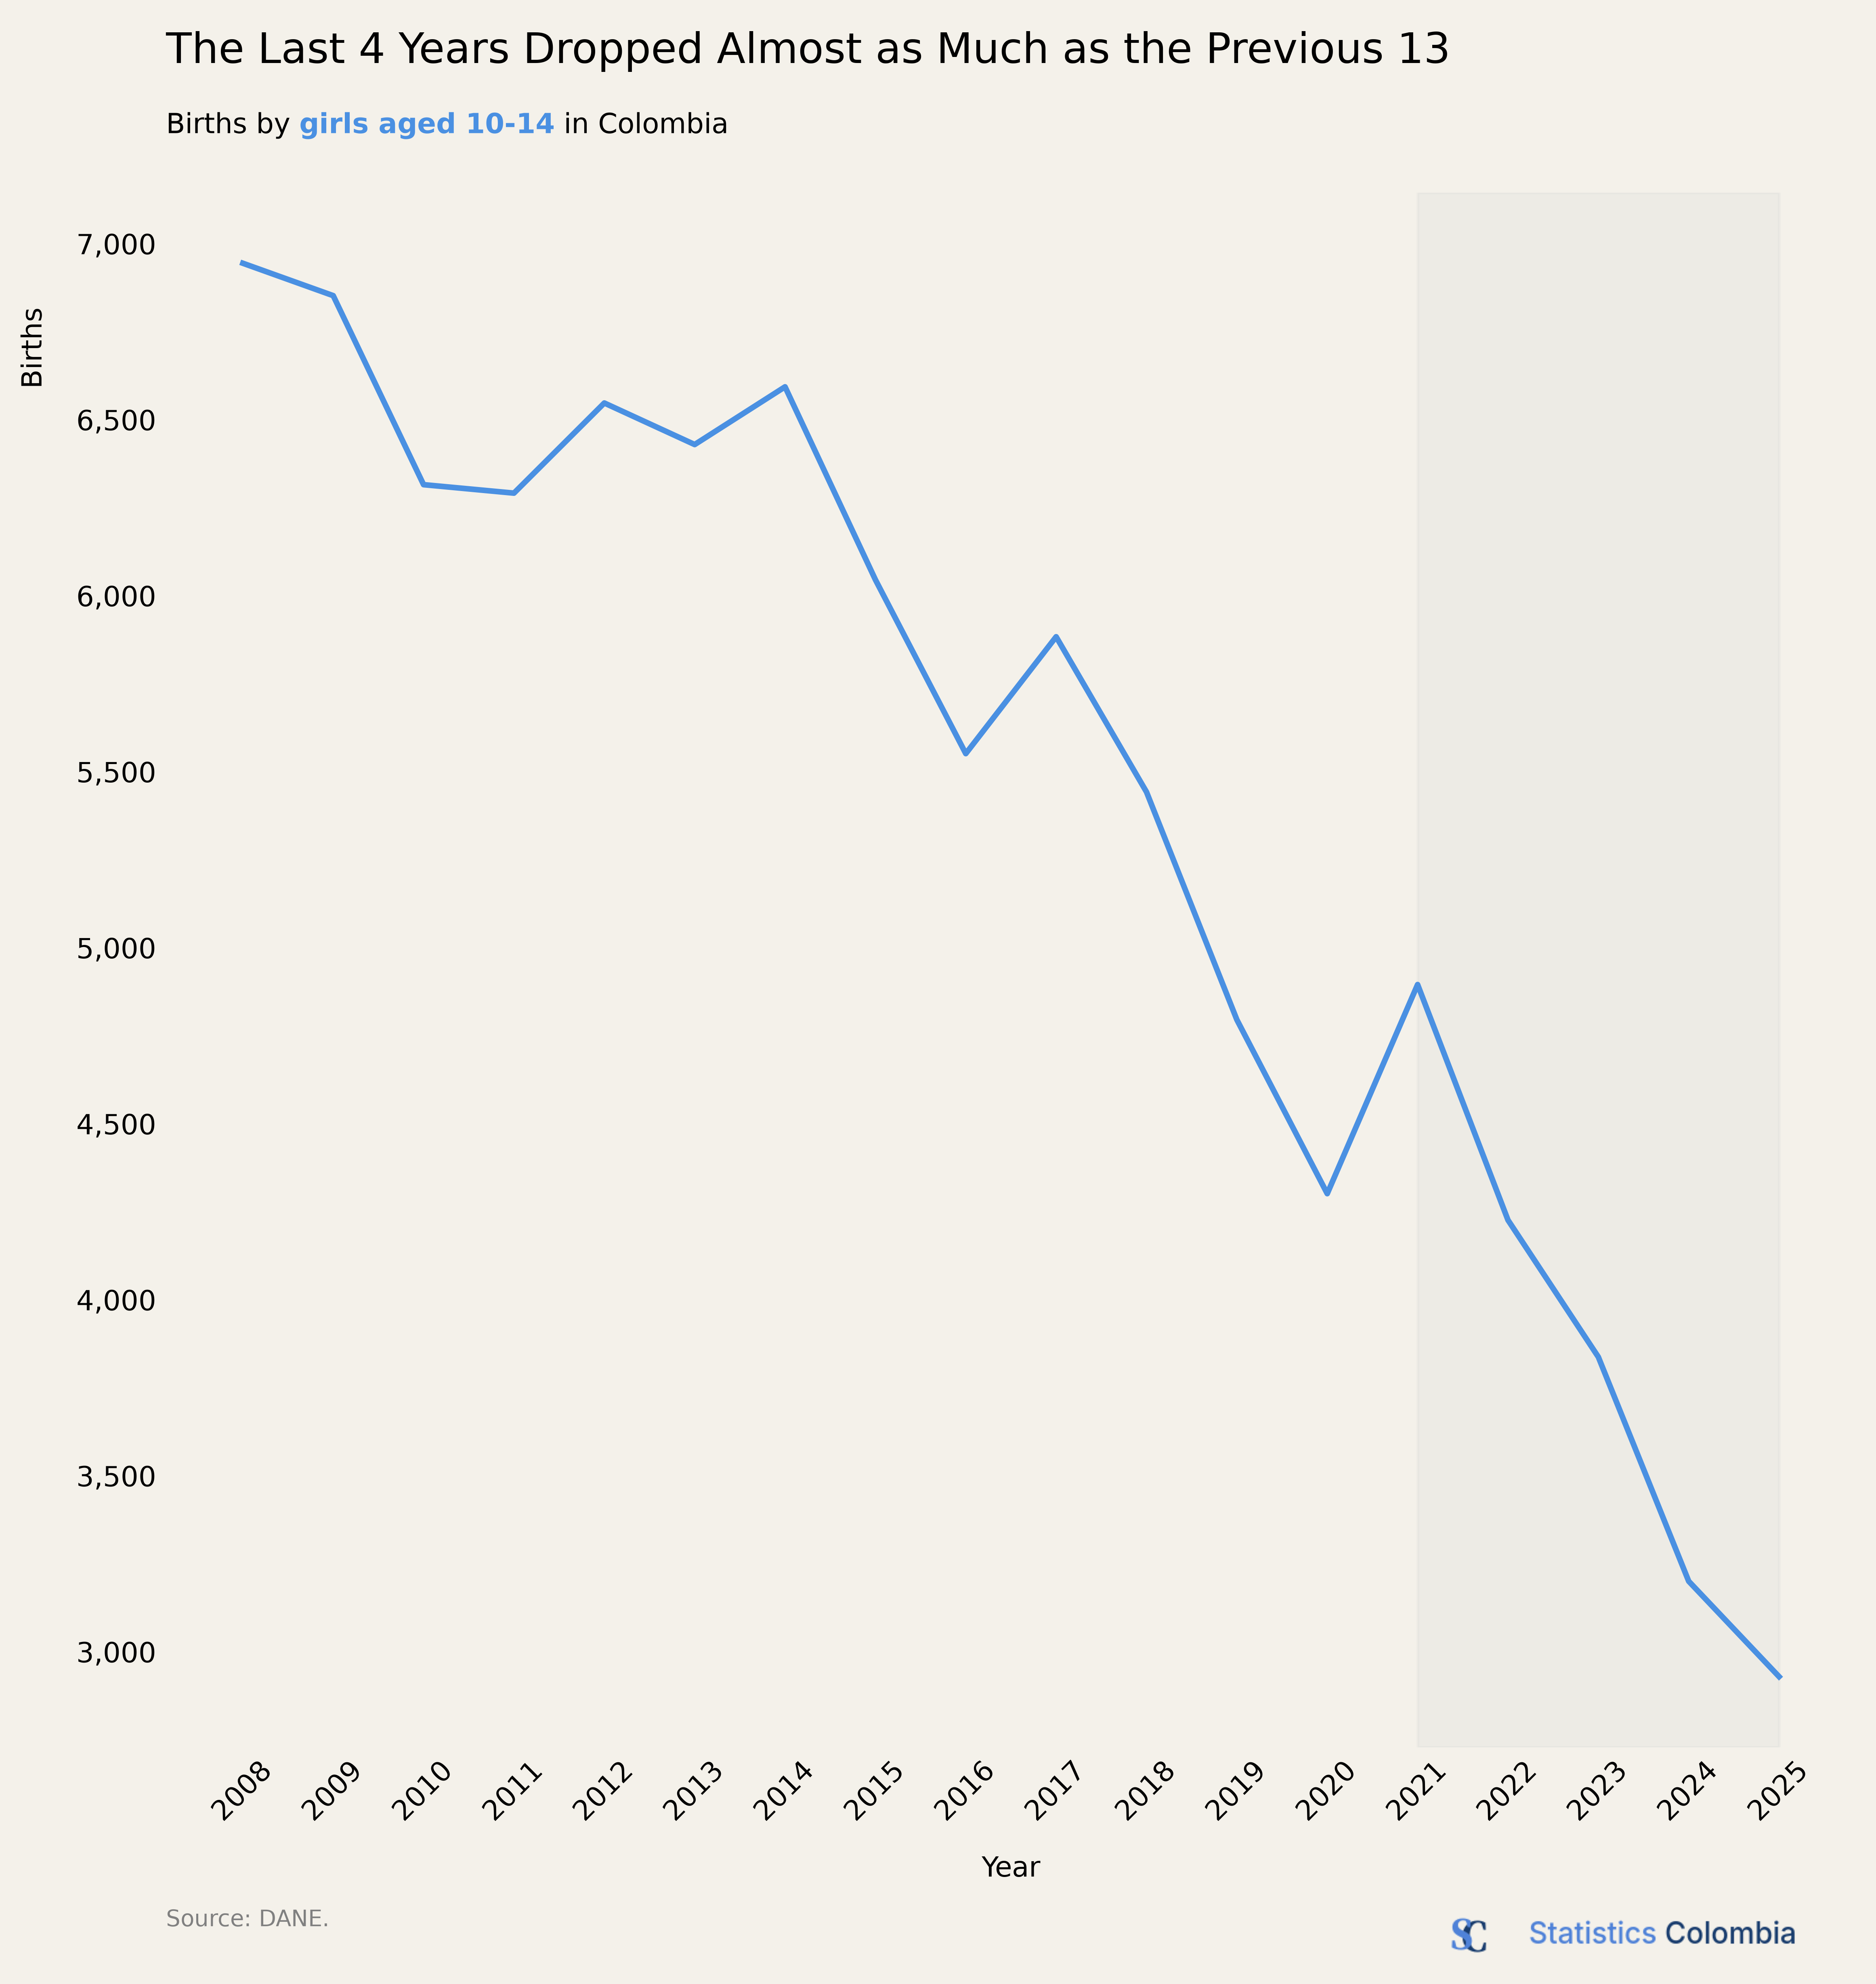

In [42]:
blue = "#4a90e2"
gray = "#D3D3D3"
background = "#F4F1EA"

fig, ax = plt.subplots(figsize=(10.8, 10), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

plt.plot(df_f, color=blue, linewidth=2)

plt.xticks(df_f.index, rotation=45)
plt.axvspan(2021, 2025, color=gray, alpha=0.2)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.ylabel("Births", labelpad=10, fontsize=10, y=0.9)
plt.xlabel("Year", labelpad=10, fontsize=10)

fig_text(
    x=0.125, y=0.96,
    s="The Last 4 Years Dropped Almost as Much as the Previous 13",
    fontsize=15
)

fig_text(
    x=0.125, y=0.92,
    s="Births by <girls aged 10-14> in Colombia",
    highlight_textprops=[{"color": blue, "weight": "bold"}],
    fontsize=10
)

fig_text(
    0.125, 0.03, 
    "Source: DANE.\n", 
    fontsize=8, color="gray",
)

imagebox = OffsetImage(logo, zoom=0.4)

ab = AnnotationBbox(imagebox, xy=(0.75, 0.025), xycoords="figure fraction",
                    frameon=False, pad=0)

plt.gca().add_artist(ab)

plt.show()